# Unbinned maximum likelihood fit

The probability densitiy function for the distribution of an angle $\alpha$ is given by

$$ f(x; a) = \frac{1 + a x}{2}, \quad x = \cos \alpha $$

The parameter $a$ is in the range $-1 \le a \le 1$.

## Tasks

a) Determine the maximum-likelihood estimate $\hat a$ of the parameter $a$ and its uncertainty from the provided data sample using a numerical minimization tool, e.g., `iminuit` (see comments below).

b) Plot the histogram representation of the data along with the fit function.

c) Determine the uncertainties $\sigma_a^-$ and $\sigma_a^+$ defined by

$$ \ln L (\hat a \pm \sigma_a) =  \ln L_\mathrm{max} - \frac{1}{2} $$

Compare your result with the result of `iminuit`'s `minos()` routine. Reduce the sample size of the data set by only taking the first $n$ events (`x[:n]`). At approximately which value of $n$ is the difference between $\sigma_a^-$ and $\sigma_a^+$ bigger than 5\%? 

Use the data generation provided in the notebook `S01_ml_02_generate_data.ipynb`. It is recommended to actually generate a `CSV` file and read it back here. You don't necessarily have to hand in your generated data; the tutors can generate their own and since your implemented procedure is generic, it should work with any other dataset generated with `S01_ml_02_generate_data.ipynb`.


### Hints

It is recommended to not start coding right away. Try to really understand how the Likelihood looks first. Realize, what the Likelihood is a function of and what it describes.

Also, the function imported as `from scipy.optimize import brentq` might come in handy.


## Comments on Python's `iminuit`

The KIP service has iminuit version 1.3.8. Please note that the most recent version is $\geq2.0.0$ and that the [documentation](https://iminuit.readthedocs.io/en/stable/) applies to *that* version. Some backward-incompatible changes have been introduced, some of which changed some interfaces. For your tasks that mainly affects the `minuit.Minuit` constructor. The following shows the construction of a `Minuit` object for version 1.3.8 (in case you use the KIP service or a version $<2.0.0$) and $\geq2.0.0$ (in case you use another service implementing a higher version), respectively.
```python
from iminuit import Minuit

def func(par1, par2, ..., parN):
    return minimise_something(par1, par2, ..., parN)

# least squares method: errordef=1
# likelihood method: errordef=0.5
m = Minuit(func, par1=0.1, par2=0.1, ..., parN=0.1, errordef=1)
```

And this would be the equivalent workflow for versions >2.0.0
```python
from iminuit import Minuit

def func(par1, par2, ..., parN):
    return minimise_something(par1, par2, ..., parN)

# least squares method: errordef=Minuit.LEAST_SQUARES
# likelihood method: errordef=Minuit.LIKELIHOOD

# add errordef as an attribute of your defined minimisation function which will be checked for when optimised
func.errordef = Minuit.LEAST_SQUARES
m = Minuit(func, par1=0.1, par2=0.1, ..., parN=0.1)
```

Another (potenitally) Jupiter related *feature* is the fact that `m.migrad()`, `m.matrix()`, `m.minos()` etc. can yield a nice summary of the respective procedure. However, in order to show it, either of these methods (and potentially others in case you use them) have to be *the last line of a code cell*. If there is *anything* coming afterwards, the output will not be printed, hence, for anything that follows, it is recommended to start a new code cell.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit

In [2]:
x = np.loadtxt("ml_fit_data.csv")

## Solutions

### MLE of $\hat{a}$ using `iminuit`

a) Determine the maximum-likelihood estimate $\hat a$ of the parameter $a$ and its uncertainty from the provided data sample using a numerical minimization tool, e.g., `iminuit`.

We are given the function for the distribution of $x$:

$$ f(x; a) = \frac{1 + a x}{2} $$

For a dataset $\vec{x}$ with $n$ values, the log-likelihood of is therefore:

\begin{align*}
    \ln L(\vec{x}; a) &= \sum \limits_{i=1}^{n} \ln f(\vec{x}; a) \\
    \ln L(\vec{x}; a) &= \sum \limits_{i=1}^{n} \ln \frac{1 + a x_i}{2}
\end{align*}

The `iminuit` module searches for the parameters which *minimize* a function, while we actually want the maximum of the log-likelihood. For the computation we therefore need to optimize the negated log-likelihood. In addition, we set the error calculation to `Minuit.LIKELIHOOD` mode, so that the uncertainties are reported correctly.

As shown below, we obtain the maximum likelihood estimate $\hat{a} = 0.19 \pm 0.05$.

To confirm the result, the log-likelihood function and the MLE parameter are plotted below. Visually we can confirm that $\hat{a}$ maximizes the likelihood of obtaining the given dataset $\vec{x}$.

In [3]:
# the given distribution of x for (fit-) parameter a
def dist_func(x, a):
    return (1 + a * x)/2

# log of likelihood function is sum of the log of the likelihoods of each value in data (vectorized function)
def log_likelihood(x_data, a):
    a = np.atleast_1d(a)
    x_data = np.atleast_1d(x_data)
    prob = dist_func(x_data[:, None], a[None, :])
    with np.errstate(invalid='ignore'):
        log_prob = np.log(prob)
    return np.sum(log_prob, axis = 0)

In [4]:
# to find the MLE, we use iminuit and the lllh function
def find_MLE_a_hat(data):
    # iminuit minimizes, so the function needs to be negated
    def negated_lllh_for_minuit(a):
        return (-log_likelihood(data, a))[0]

    m = Minuit(negated_lllh_for_minuit, a = -1)
    # for MLE, error needs to be set
    m.errordef = Minuit.LIKELIHOOD
    m.migrad()

    # read out a_hat MLE parameter and the resulting maximum log-likelihood
    a_hat = m.values[0]
    lllh_max = log_likelihood(data, a_hat)
    return a_hat, lllh_max, m

# read out values and report them nicely
a_param, lllh_max, m = find_MLE_a_hat(x)
print(f'a_hat = {np.round(a_param, 5)} ± {np.round(m.errors[0], 5)}')
print(f'ln L_max = {np.round(lllh_max[0], 5)}')
m.minos()

a_hat = 0.19203 ± 0.05225
ln L_max = -686.54099


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 686.5                      │              Nfcn = 34               │
│ EDM = 3.82e-06 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │   0.19    │   0.05    │   -0.05    │    0.05    │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┐
│          │           a           │
├──────────┼───────────┬───────────┤
│  Error   │   -0.05   │   0.05    │
│  Valid   │   True    │   True    │
│ At Limit │   False   │   False   │
│ Max FCN  │   False   │   False   │
│ New Min  │   False   │   False   │
└──────────┴───────────┴───────────┘
┌───┬─────────┐
│   │       a │
├───┼─────────┤
│ a │ 0.00273 │
└───┴─────────┘

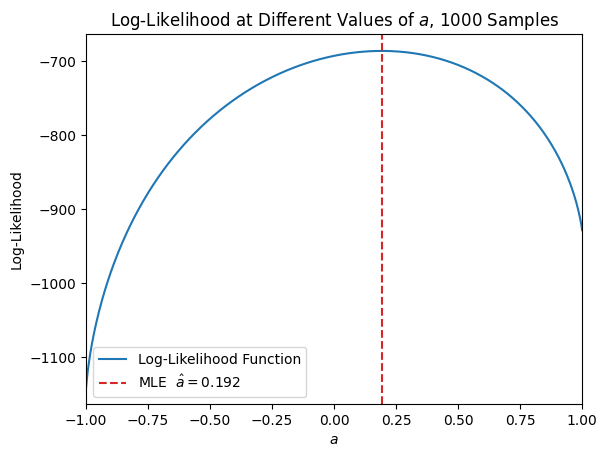

In [5]:
# plot lllh function for a dataset along with the MLE result a_hat
def plot_lllh(data, a_hat) -> None:
    alims = (-1, 1)
    a_grid = np.linspace(*alims, 500)
    lllh_grid = log_likelihood(data, a_grid)

    plt.plot(a_grid, lllh_grid, label = 'Log-Likelihood Function')
    plt.axvline(a_hat, ls = 'dashed', color = 'tab:red', label = f'MLE  $\\hat{{a}} = {np.round(a_hat, 3)}$')
    plt.title(f'Log-Likelihood at Different Values of $a$, {len(data)} Samples')
    plt.xlabel(r'$a$')
    plt.ylabel('Log-Likelihood')
    plt.xlim(alims)
    plt.legend(loc = 'lower left')
    plt.show();

plot_lllh(x, a_param)

### Histogram of Data with Fit Function

b) Plot the histogram representation of the data along with the fit function.

We plot the histogram of the data and the distribution function (using our determined fit parameter $\hat{a}$) on the same graph.

We make sure to graph the histogram using density/relative frequency. This ensures that we have the same scaling for both elements in the graph, which visually shows that the shape of the histogram matches relatively well with the distribution. We can therefore see that the type of distribution is correct and that the estimate $\hat{a}$ for the parameter $a$ is generally accurate. The next section on errors will show this numerically.

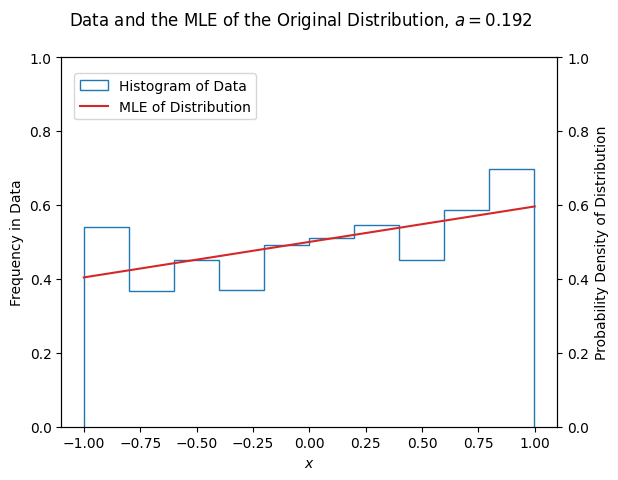

In [6]:
# create points at which to evaluate the function
x_grid = np.linspace(-1, 1, 200)
dist_grid = dist_func(x_grid, a_param)

fig, ax1 = plt.subplots()

# create histogram in density mode, set axes
ax1.hist(x, 10, histtype='step', density=True, label = 'Histogram of Data')
ax1.set_ylim((0, 1))
ax1.set_xlim((-1.1,1.1))
ax1.set_ylabel('Frequency in Data')
ax1.set_xlabel(r'$x$')

# create distribution plot on same graph, set axes same as before
ax2 = ax1.twinx()
ax2.plot(x_grid, dist_grid, color = 'tab:red', label = 'MLE of Distribution')
ax2.set_ylim((0, 1))
ax2.set_ylabel('Probability Density of Distribution')

fig.suptitle(f'Data and the MLE of the Original Distribution, $a = {np.round(a_param, 4)}$')
fig.legend(loc=(0.12, 0.75));

### Determining Uncertainties

c) Determine the uncertainties $\sigma_a^-$ and $\sigma_a^+$ (defined above). Compare your result with the result of `iminuit`'s `minos()` routine. Reduce the sample size of the data set by only taking the first $n$ events (`x[:n]`). At approximately which value of $n$ is the difference between $\sigma_a^-$ and $\sigma_a^+$ bigger than $5\%$?

Using the definition of $\sigma_a^-$ and $\sigma_a^+$, we can rearrange the equation to define a new function $f$. The roots of this function give the desired solutions (the values of $\hat a \pm \sigma_a$).

\begin{align*}
    \ln L_\mathrm{max} - \frac{1}{2} &= \ln L (\hat a \pm \sigma_a) \\
    f(\hat a \pm \sigma_a) = 0 &= \ln L (\hat a \pm \sigma_a)  - \big( \ln L_\mathrm{max} - \frac{1}{2} \big)
\end{align*}

Now we can use the standard `scipy.optimize.root_scalar` function to find these roots and solve for the positive and negative deviations from $\hat a$.

\begin{gather*}
    f(\hat a \pm \sigma_a) = 0 \\
    \Rightarrow a^+ = \hat a + \sigma_a^+ \\
    \Rightarrow a^- = \hat a - \sigma_a^- \\
    \sigma_a^+ = a^+ - \hat a \\
    \sigma_a^- = \hat a - a^-
\end{gather*}

We select some interesting numbers of events for which to try the MLE method. Clearly very small samples have very large errors and have no power to accurately determine the parameter $a$. The errors are not just large, but also unbalanced: The difference between $\sigma^+$ and $\sigma^-$ is large.

The $\hat a$ estimate appears to converge relatively quickly. However, we see that even reducing the sample number by only $10$, to $n = 990$, the difference between $\sigma^+$ and $\sigma^-$ already grows to over $5 \%$. This value seems to converge much more slowly.

We can also observe that (at least with this dataset) the difference in errors does not monotonically reduce with sample size. For example, from $200$ to $750$ samples the difference increases by about $4$ percentage points. From $n = 995$ to $n = 996$ the difference also jumps up, although after this point it reduces sharply. At the maximum number of samples, we include the entire dataset and $n = 1000$. At this point the difference in errors is only $1.4 \%$.


In [7]:
from scipy.optimize import root_scalar

# calculate percent difference between sigma_minus and sigma_plus
def percent_difference(a, b):
    mean = (a + b) / 2
    difference = abs(a - b)
    return difference/mean * 100

# highlight if the percent difference is smaller than 5 %
def print_and_check_size(val) -> None:
    SIZE = 5
    if val > SIZE:
        print(f'difference  = {np.round(val, 3)} %')
        return
    print(f'difference  = {np.round(val, 3)} %     <---------- <= 5 %')

# to find a+ and a-, we find the root of this function (which a values make it zero?)
def find_my_root(a, data, lllh_max):
    return (log_likelihood(data, a) - (lllh_max - 0.5)).item()

# we use scipy to find the values of a which make the function zero (the roots)
def find_sigma_pm(data, a_hat, lllh_max):
    sol = root_scalar(
        lambda a: find_my_root(a, data, lllh_max),
        bracket=[-1, a_hat]
    )
    sigma_minus = abs(a_hat - sol.root)

    sol = root_scalar(
        lambda a: find_my_root(a, data, lllh_max),
        bracket=[a_hat, 1]
    )
    sigma_plus = abs(a_hat - sol.root)
    return sigma_minus, sigma_plus

# we condense finding the MLE, finding sigma±, and printing the values into one function
def find_MLE_with_error(data, show_details: bool) -> None:
    a_hat, lllh_max, m = find_MLE_a_hat(data)
    # plot_lllh(data, a_hat)
    sigma_minus, sigma_plus = find_sigma_pm(data, a_param, lllh_max)
    difference = percent_difference(sigma_minus, sigma_plus)
    FIGS = 5
    print(f'===== MLE with n = {len(data)} Samples =====')
    if show_details:
        print(f'a_hat       = {np.round(a_hat, FIGS)}')
        print(f'sigma_minus = {np.round(sigma_minus, FIGS)}')
        print(f'sigma_plus  = {np.round(sigma_plus, FIGS)}')
    print_and_check_size(difference)

# for given sizes of data, we slice x at that index to only take some of the data
list_of_sample_sizes = [50, 200, 750, 990, 994, 995, 996, 997, None]
list_of_show_details = [True, False, False, True, True, True, True, True, True]

for n_samples, show_details in zip(list_of_sample_sizes, list_of_show_details):
    find_MLE_with_error(x[:n_samples], show_details)

===== MLE with n = 50 Samples =====
a_hat       = 0.23445
sigma_minus = 0.21206
sigma_plus  = 0.28475
difference  = 29.264 %
===== MLE with n = 200 Samples =====
difference  = 18.666 %
===== MLE with n = 750 Samples =====
difference  = 22.623 %
===== MLE with n = 990 Samples =====
a_hat       = 0.18614
sigma_minus = 0.05894
sigma_plus  = 0.04637
difference  = 23.863 %
===== MLE with n = 994 Samples =====
a_hat       = 0.19002
sigma_minus = 0.05484
sigma_plus  = 0.05006
difference  = 9.114 %
===== MLE with n = 995 Samples =====
a_hat       = 0.19193
sigma_minus = 0.05287
sigma_plus  = 0.05191
difference  = 1.833 %     <---------- <= 5 %
===== MLE with n = 996 Samples =====
a_hat       = 0.18984
sigma_minus = 0.05494
sigma_plus  = 0.04981
difference  = 9.795 %
===== MLE with n = 997 Samples =====
a_hat       = 0.19159
sigma_minus = 0.05314
sigma_plus  = 0.0515
difference  = 3.13 %     <---------- <= 5 %
===== MLE with n = 1000 Samples =====
a_hat       = 0.19203
sigma_minus = 0.05261
sig

In [8]:
MINOS
raise Error()

NameError: name 'MINOS' is not defined